In [1]:
import os
import sys
import json
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path

# Import Mask RCNN
from mrcnn.config import Config
from mrcnn import model as modellib, utils
from mrcnn import visualize

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
ROOT_DIR = r"D:\HomeWorkOrDeadline\Artificial_Intelligence_for_Engineering\Week5\task2"
DATASET_DIR = os.path.join(ROOT_DIR, "log-images")
MODEL_DIR = os.path.join(ROOT_DIR, "logs")
OUTPUT_DIR = os.path.join(ROOT_DIR, "rcnn_test")
COCO_WEIGHTS_PATH = os.path.join(ROOT_DIR, "mask_rcnn_coco.h5")

# Create directories
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Directories configured:")
print(f"  Dataset: {DATASET_DIR}")
print(f"  Models: {MODEL_DIR}")
print(f"  Output: {OUTPUT_DIR}")

✓ Directories configured:
  Dataset: D:\HomeWorkOrDeadline\Artificial_Intelligence_for_Engineering\Week5\task2\log-images
  Models: D:\HomeWorkOrDeadline\Artificial_Intelligence_for_Engineering\Week5\task2\logs
  Output: D:\HomeWorkOrDeadline\Artificial_Intelligence_for_Engineering\Week5\task2\rcnn_test


In [3]:
if not os.path.exists(COCO_WEIGHTS_PATH):
    print("Downloading COCO pre-trained weights...")
    import urllib.request
    COCO_WEIGHTS_URL = "https://github.com/matterport/Mask_RCNN/releases/download/v2.0/mask_rcnn_coco.h5"
    urllib.request.urlretrieve(COCO_WEIGHTS_URL, COCO_WEIGHTS_PATH)
    print("✓ Download complete!")
else:
    print("✓ COCO weights already downloaded")

✓ COCO weights already downloaded


In [4]:
class LogConfig(Config):
    """Configuration for wooden log detection."""
    NAME = "wooden_log"
    IMAGES_PER_GPU = 1
    NUM_CLASSES = 1 + 1  # Background + log
    STEPS_PER_EPOCH = 50
    DETECTION_MIN_CONFIDENCE = 0.7
    IMAGE_MIN_DIM = 128
    IMAGE_MAX_DIM = 128
    RPN_ANCHOR_SCALES = (8, 16, 32, 64, 128)
    TRAIN_ROIS_PER_IMAGE = 32

config = LogConfig()
print("✓ Configuration created")
config.display()

✓ Configuration created

Configurations:
BACKBONE                       resnet101
BACKBONE_STRIDES               [4, 8, 16, 32, 64]
BATCH_SIZE                     1
BBOX_STD_DEV                   [0.1 0.1 0.2 0.2]
COMPUTE_BACKBONE_SHAPE         None
DETECTION_MAX_INSTANCES        100
DETECTION_MIN_CONFIDENCE       0.7
DETECTION_NMS_THRESHOLD        0.3
FPN_CLASSIF_FC_LAYERS_SIZE     1024
GPU_COUNT                      1
GRADIENT_CLIP_NORM             5.0
IMAGES_PER_GPU                 1
IMAGE_CHANNEL_COUNT            3
IMAGE_MAX_DIM                  128
IMAGE_META_SIZE                14
IMAGE_MIN_DIM                  128
IMAGE_MIN_SCALE                0
IMAGE_RESIZE_MODE              square
IMAGE_SHAPE                    [128 128   3]
LEARNING_MOMENTUM              0.9
LEARNING_RATE                  0.001
LOSS_WEIGHTS                   {'rpn_class_loss': 1.0, 'rpn_bbox_loss': 1.0, 'mrcnn_class_loss': 1.0, 'mrcnn_bbox_loss': 1.0, 'mrcnn_mask_loss': 1.0}
MASK_POOL_SIZE                 14

In [5]:
class LogDataset(utils.Dataset):
    """Dataset for wooden log detection."""
    
    def load_logs(self, dataset_dir, subset):
        """Load images and annotations."""
        self.add_class("log", 1, "log")
        
        # Get all JSON files
        annotations = []
        for filename in os.listdir(dataset_dir):
            if filename.endswith('.json'):
                json_path = os.path.join(dataset_dir, filename)
                with open(json_path, 'r') as f:
                    ann = json.load(f)
                    image_filename = ann['imagePath']
                    image_path = os.path.join(dataset_dir, image_filename)
                    
                    if os.path.exists(image_path):
                        annotations.append({
                            'json_path': json_path,
                            'image_path': image_path,
                            'annotation': ann
                        })
        
        # Split: 8 train, 2 test
        random.shuffle(annotations)
        if subset == "train":
            annotations = annotations[:8]
        else:
            annotations = annotations[8:10]
        
        # Add images
        for idx, ann_data in enumerate(annotations):
            ann = ann_data['annotation']
            self.add_image(
                "log",
                image_id=idx,
                path=ann_data['image_path'],
                width=ann['imageWidth'],
                height=ann['imageHeight'],
                annotation=ann
            )
    
    def load_mask(self, image_id):
        """Generate masks for image - FIXED VERSION."""
        info = self.image_info[image_id]
        ann = info['annotation']
        shapes = ann.get('shapes', [])
        
        if len(shapes) == 0:
            return np.zeros([info['height'], info['width'], 1], dtype=np.uint8), np.array([0])
        
        height, width = info['height'], info['width']
        masks = []
        class_ids = []
        
        for shape in shapes:
            # Get points
            points = np.array(shape['points'], dtype=np.int32)
            
            # Create mask for this shape
            mask = np.zeros([height, width], dtype=np.uint8)
            cv2.fillPoly(mask, [points], 255)  # Use 255 instead of 1 for visibility
            
            masks.append(mask)
            class_ids.append(1)  # log class ID
        
        # Stack masks
        if masks:
            mask = np.stack(masks, axis=2).astype(np.bool_)
        else:
            mask = np.zeros([height, width, 1], dtype=np.bool_)
        
        return mask, np.array(class_ids, dtype=np.int32)
    
    def image_reference(self, image_id):
        return self.image_info[image_id]["path"]

print("✓ Dataset class fixed and ready!")

✓ Dataset class fixed and ready!


✓ Training images: 8
✓ Test images: 2


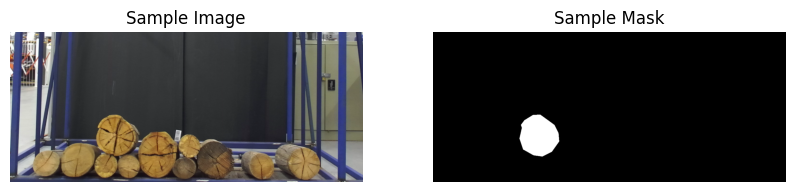

In [6]:
# Training dataset
dataset_train = LogDataset()
dataset_train.load_logs(DATASET_DIR, "train")
dataset_train.prepare()

# Test dataset
dataset_val = LogDataset()
dataset_val.load_logs(DATASET_DIR, "test")
dataset_val.prepare()

print(f"✓ Training images: {len(dataset_train.image_ids)}")
print(f"✓ Test images: {len(dataset_val.image_ids)}")

# Visualize a sample
if len(dataset_train.image_ids) > 0:
    image_id = dataset_train.image_ids[0]
    image = dataset_train.load_image(image_id)
    mask, class_ids = dataset_train.load_mask(image_id)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Sample Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(mask[:, :, 0], cmap='gray')
    plt.title("Sample Mask")
    plt.axis('off')
    plt.show()


In [7]:
print("\nCreating model...")
model = modellib.MaskRCNN(mode="training", config=config, model_dir=MODEL_DIR)

print("Loading COCO weights...")
model.load_weights(COCO_WEIGHTS_PATH, by_name=True, exclude=[
    "mrcnn_class_logits", "mrcnn_bbox_fc", "mrcnn_bbox", "mrcnn_mask"])

print("\nStarting training...")
print("=" * 60)
model.train(dataset_train, dataset_val,
            learning_rate=config.LEARNING_RATE,
            epochs=10,
            layers='heads')
print("=" * 60)
print("✓ Training complete!")


Creating model...
Loading COCO weights...

Starting training...

Starting at epoch 0. LR=0.001

Checkpoint Path: D:\HomeWorkOrDeadline\Artificial_Intelligence_for_Engineering\Week5\task2\logs\wooden_log20251012T1805\mask_rcnn_wooden_log_{epoch:04d}.h5
Selecting layers to train
fpn_c5p5               (Conv2D)
fpn_c4p4               (Conv2D)
fpn_c3p3               (Conv2D)
fpn_c2p2               (Conv2D)
fpn_p5                 (Conv2D)
fpn_p2                 (Conv2D)
fpn_p3                 (Conv2D)
fpn_p4                 (Conv2D)
rpn_model              (Functional)
mrcnn_mask_conv1       (TimeDistributed)
mrcnn_mask_bn1         (TimeDistributed)
mrcnn_mask_conv2       (TimeDistributed)
mrcnn_mask_bn2         (TimeDistributed)
mrcnn_class_conv1      (TimeDistributed)
mrcnn_class_bn1        (TimeDistributed)
mrcnn_mask_conv3       (TimeDistributed)
mrcnn_mask_bn3         (TimeDistributed)
mrcnn_class_conv2      (TimeDistributed)
mrcnn_class_bn2        (TimeDistributed)
mrcnn_mask_conv4   

C:\ProgramData\anaconda3\envs\maskrcnn\lib\site-packages\tensorflow\python\framework\indexed_slices.py:431: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


50/50 [==============================] - ETA: 0s - batch: 24.5000 - size: 1.0000 - loss: 1.8711 - rpn_class_loss: 0.0900 - rpn_bbox_loss: 0.5178 - mrcnn_class_loss: 0.1893 - mrcnn_bbox_loss: 0.6056 - mrcnn_mask_loss: 0.4684WARNING:tensorflow:From C:\ProgramData\anaconda3\envs\maskrcnn\lib\site-packages\tensorflow\python\keras\engine\training_v1.py:2048: Model.state_updates (from tensorflow.python.keras.engine.training) is deprecated and will be removed in a future version.
Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
50/50 [==============================] - 146s 3s/step - batch: 24.5000 - size: 1.0000 - loss: 1.8711 - rpn_class_loss: 0.0900 - rpn_bbox_loss: 0.5178 - mrcnn_class_loss: 0.1893 - mrcnn_bbox_loss: 0.6056 - mrcnn_mask_loss: 0.4684 - val_loss: 1.4315 - val_rpn_class_loss: 0.0704 - val_rpn_bbox_loss: 0.4847 - val_mrcnn_class_loss: 0.1019 - val_mrcnn_bbox_loss: 0.3670 - val_mrcnn_mask_loss: 0.4075
Epoch 2/1

Loading weights from: D:\HomeWorkOrDeadline\Artificial_Intelligence_for_Engineering\Week5\task2\logs\wooden_log20251012T1805\mask_rcnn_wooden_log_0010.h5
Re-starting from epoch 10

Testing on test images...

img_0099.png: 11 log(s) detected


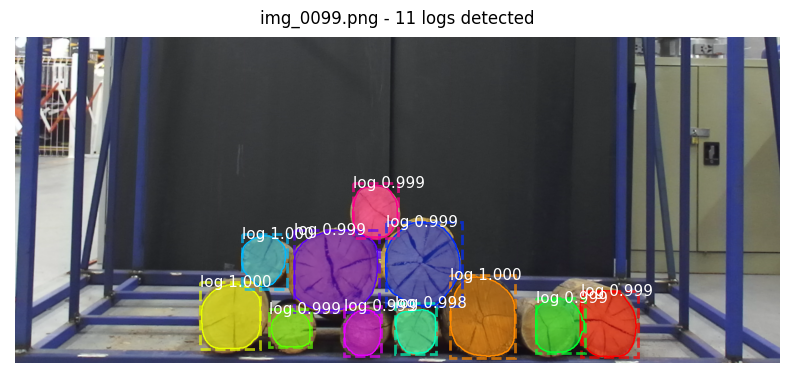


img_0112.png: 11 log(s) detected


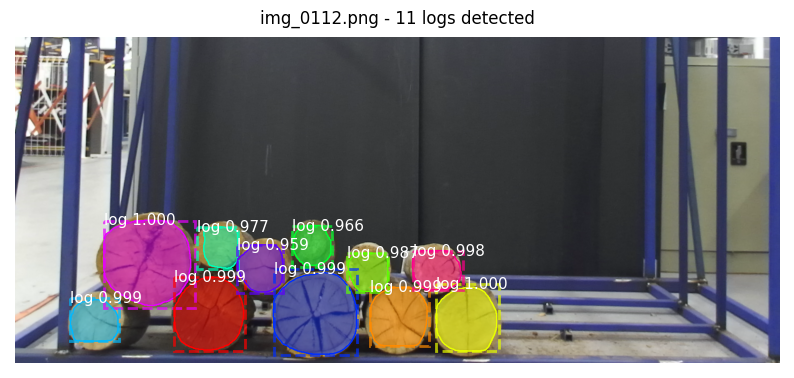


✓ TASK 2 COMPLETE!
✓ Output saved to: D:\HomeWorkOrDeadline\Artificial_Intelligence_for_Engineering\Week5\task2\rcnn_test

Generated files:
  - detected_*.png (with masks)
  - counted_*.png (with count overlay)


In [10]:
class InferenceConfig(LogConfig):
    GPU_COUNT = 1
    IMAGES_PER_GPU = 1

inference_config = InferenceConfig()
model = modellib.MaskRCNN(mode="inference", config=inference_config, model_dir=MODEL_DIR)

# Load trained weights
model_path = model.find_last()
print(f"Loading weights from: {model_path}")
model.load_weights(model_path, by_name=True)

print("\nTesting on test images...")
print("=" * 60)

for image_id in dataset_val.image_ids:
    # Load image
    image = dataset_val.load_image(image_id)
    image_path = dataset_val.image_reference(image_id)
    image_name = os.path.basename(image_path)
    
    # Detect
    results = model.detect([image], verbose=0)[0]
    num_logs = len(results['class_ids'])
    
    print(f"\n{image_name}: {num_logs} log(s) detected")
    
    # Visualize with matplotlib
    fig, ax = plt.subplots(figsize=(10, 10))
    visualize.display_instances(
        image, results['rois'], results['masks'], results['class_ids'],
        dataset_val.class_names, results['scores'], ax=ax,
        title=f"{image_name} - {num_logs} logs detected"
    )
    output_path = os.path.join(OUTPUT_DIR, f"detected_{image_name}")
    plt.savefig(output_path, bbox_inches='tight', dpi=150)
    plt.show()
    
    # Create OpenCV version with boxes and scores
    image_cv = image.copy()
    for i in range(len(results['rois'])):
        y1, x1, y2, x2 = results['rois'][i]
        score = results['scores'][i]
        
        cv2.rectangle(image_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"log: {score:.2f}"
        cv2.putText(image_cv, label, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Add count
    count_text = f"Total Logs: {num_logs}"
    cv2.putText(image_cv, count_text, (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    output_cv_path = os.path.join(OUTPUT_DIR, f"counted_{image_name}")
    cv2.imwrite(output_cv_path, cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR))

print("\n" + "=" * 60)
print("✓ TASK 2 COMPLETE!")
print("=" * 60)
print(f"✓ Output saved to: {OUTPUT_DIR}")
print("\nGenerated files:")
print("  - detected_*.png (with masks)")
print("  - counted_*.png (with count overlay)")

In [9]:
def count_logs_in_image(image_path):
    """Count logs in a single image and return count + confidence scores."""
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    results = model.detect([image_rgb], verbose=0)[0]
    num_logs = len(results['class_ids'])
    
    print(f"\nImage: {os.path.basename(image_path)}")
    print(f"Logs detected: {num_logs}")
    
    for i, score in enumerate(results['scores'], 1):
        print(f"  Log {i}: Confidence = {score:.2%}")
    
    return num_logs, results

print("✓ Log counting function ready!")
print("\nExample usage:")
print("  count_logs_in_image('path/to/image.png')")

✓ Log counting function ready!

Example usage:
  count_logs_in_image('path/to/image.png')
